In [1]:
from google.colab import files
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import io # Import io for reading byte content

uploaded = files.upload()

# Assuming only one file is uploaded and it's a CSV
df = None
if uploaded:
    filename = list(uploaded.keys())[0]
    uploaded_file_content = uploaded[filename]
    print(f'User uploaded file "{filename}" with length {len(uploaded_file_content)} bytes')

    # Read the byte content into a pandas DataFrame, assuming CSV format
    try:
        df = pd.read_csv(io.BytesIO(uploaded_file_content))
        print(f'Successfully loaded "{filename}" into a pandas DataFrame.')
        display(df.head()) # Display the first 5 rows to confirm
    except Exception as e:
        print(f'Error reading file into DataFrame: {e}')
else:
    print('No file was uploaded.')

Saving train.csv to train.csv
User uploaded file "train.csv" with length 18190568 bytes
Successfully loaded "train.csv" into a pandas DataFrame.


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,0.0,0.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,1.0,...,0.0,2.0,0.0,0.0,0.0,1.0,2.0,4.0,5.0,0.0
1,1.0,0.0,1.0,23.0,1.0,0.0,0.0,1.0,1.0,1.0,...,0.0,2.0,0.0,0.0,0.0,1.0,13.0,4.0,7.0,0.0
2,1.0,1.0,1.0,29.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,9.0,6.0,8.0,0.0
3,1.0,1.0,1.0,39.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,0.0,0.0,1.0,7.0,4.0,7.0,0.0
4,0.0,1.0,1.0,16.0,1.0,0.0,0.0,1.0,1.0,1.0,...,1.0,5.0,30.0,30.0,1.0,0.0,7.0,5.0,1.0,0.0


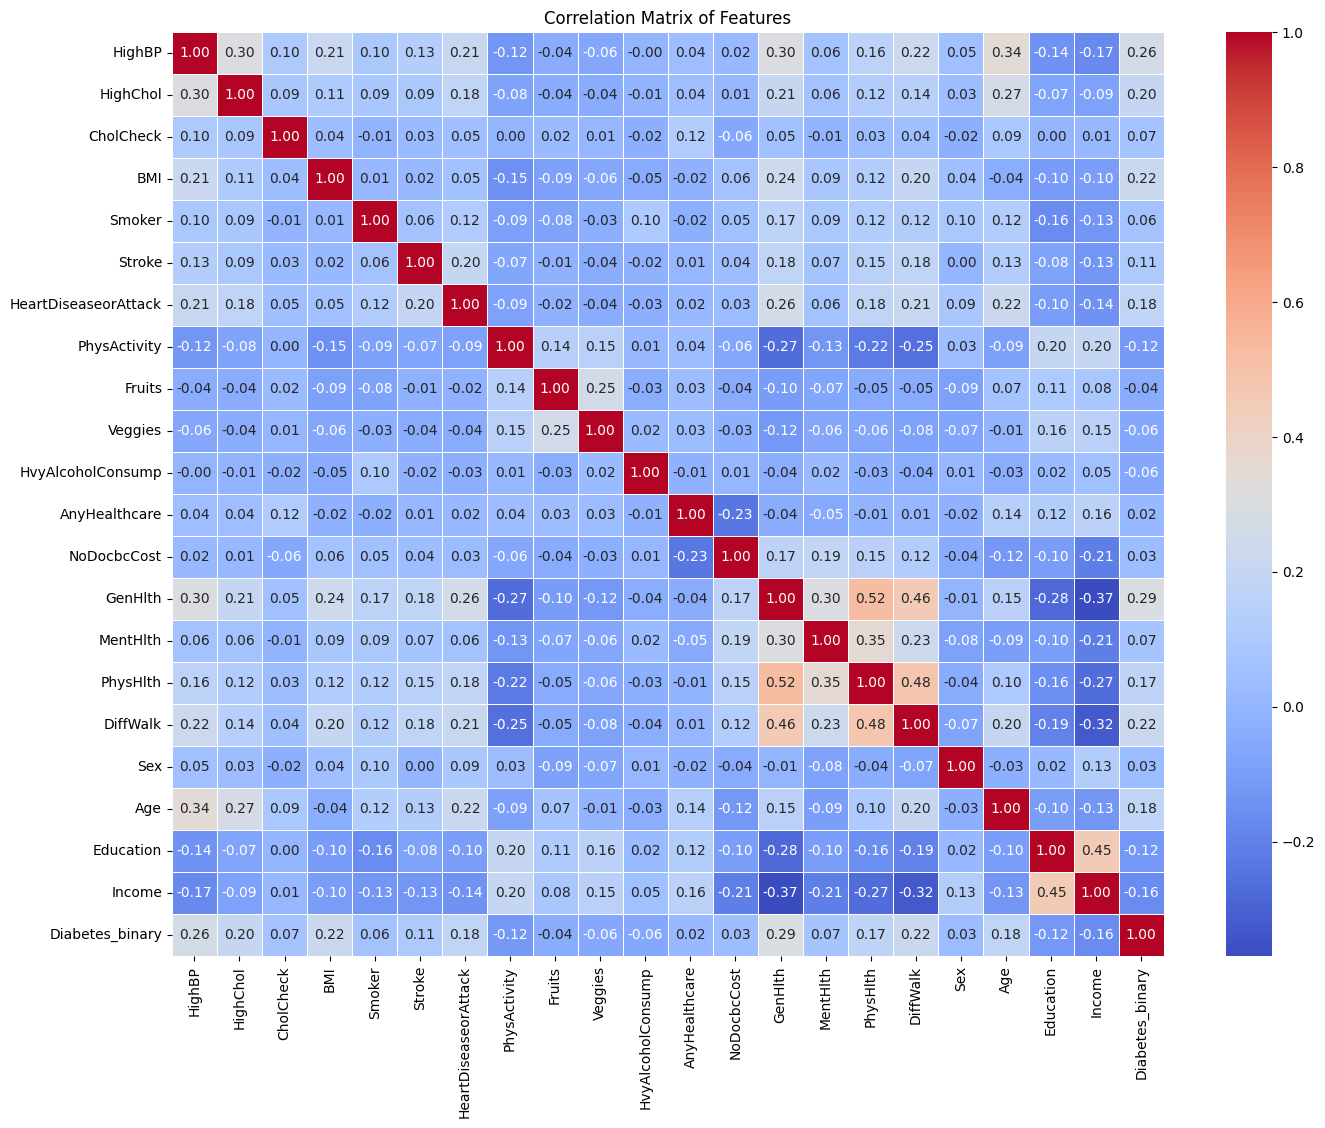

/tmp/ipykernel_644/1100630805.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_series.values, y=mi_series.index, palette='viridis')


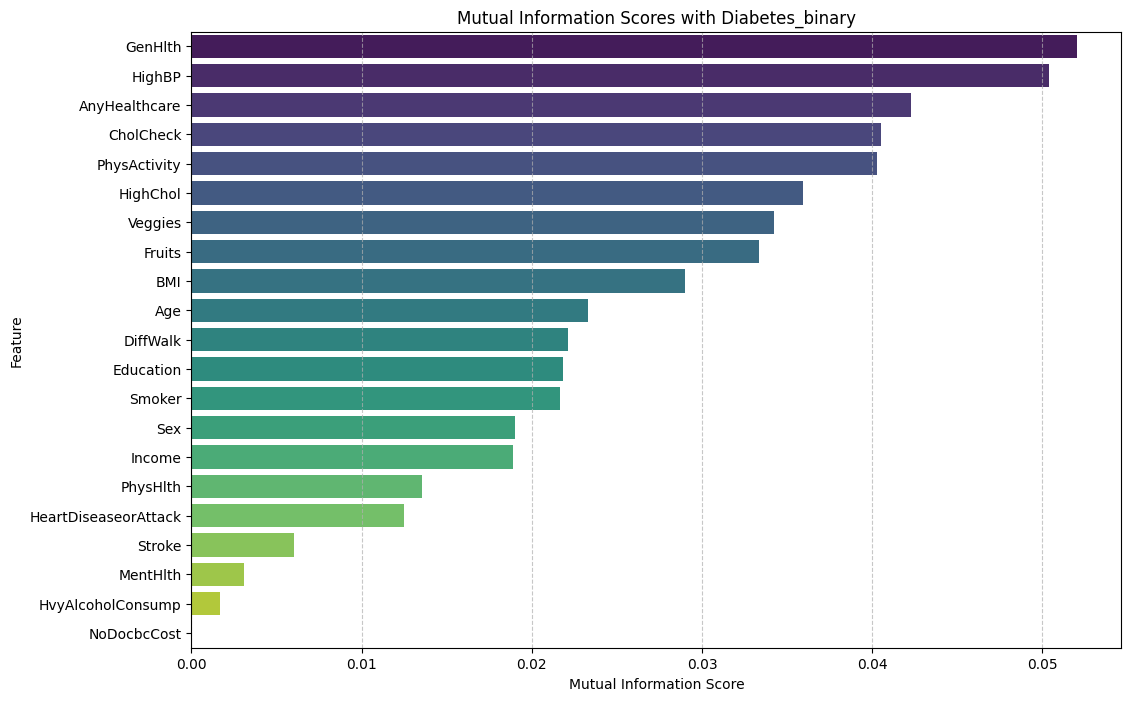

In [2]:

# Calculate the correlation matrix
corr_matrix = df.corr()

# Plotting the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features')
plt.show()


from sklearn.feature_selection import mutual_info_classif

# Calculate Mutual Information scores between features and the target variable 'Diabetes_binary'
# We use the original 'df' with the target column for MI calculation

# Ensure all features are numerical for MI calculation
# If there are categorical features, they should ideally be one-hot encoded or handled appropriately
# For this dataset, assuming all relevant features are numerical or can be treated as such for MI

x_mi = df.drop('Diabetes_binary', axis=1)
y_mi = df['Diabetes_binary']

# Convert all features to numeric, coercing errors to NaN and then filling them if necessary
# This step is crucial if the data contains non-numeric types after initial load
for col in x_mi.columns:
    if x_mi[col].dtype == 'object' or x_mi[col].dtype == 'category':
        # For simplicity, convert categorical objects to numerical using factorize or one-hot encode
        # Here, assuming they are binary or can be directly converted for MI_classif
        x_mi[col] = pd.factorize(x_mi[col])[0]
    x_mi[col] = pd.to_numeric(x_mi[col], errors='coerce')

# Fill any NaN values that might have been introduced by coercion for MI calculation
x_mi = x_mi.fillna(x_mi.mean())


mi_scores = mutual_info_classif(x_mi, y_mi, random_state=42)
mi_series = pd.Series(mi_scores, index=x_mi.columns)

# Sort the scores for better visualization
mi_series = mi_series.sort_values(ascending=False)

# Plotting the MI scores
plt.figure(figsize=(12, 8))
sns.barplot(x=mi_series.values, y=mi_series.index, palette='viridis')
plt.title('Mutual Information Scores with Diabetes_binary')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from google.colab import files

# Save the DataFrame to a CSV file in the Colab environment
df.to_csv('downloaded_data.csv', index=False)

# Download the file to your local machine
files.download('downloaded_data.csv')

print('The DataFrame `df` has been downloaded as downloaded_data.csv.')